In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.integrate import odeint
import pandas as pd

#### Parameters

In [19]:
p = {
    'kk_1':  0.5,   
    'kk_2':  0.5,   
    'C50': 1.0,    
    'C_total': 2.0,
    'alpha_1': 0,
    'alpha_2': 0,
    'alpha_1_part': 0.5,
    'alpha_2_part': 0.5,
    'K':     1.0,    
    'beta':     0.2,    
    'mu':    0.1,    
    'rH':    0.1,   
    'rhor':  0.05,   
    'm':    3.2e-5  
}

#### Initial conditions

In [21]:
y0 = [0.95,     
      0.05,   
      0.0,
      0.0,
      0.0]   
t = np.linspace(0, 2000, 50)

#### Transmission rates and fungicide efficacy

In [22]:
def Hills_function (C, kk, C50):
    if C <= 0:
        return 0.0
    return (kk * C/ (C + C50))

def dose_distribution(C_total, r_2):
    C_dose1 = C_total * (1 - r_2)
    C_dose2  = C_total * r_2
    return C_dose1, C_dose2 
    
C_dose1, C_dose2 = dose_distribution(p['C_total'], 0.5)

# Efficacies per fungicide
#scenario 1: alpha = 0
e_1 = Hills_function(C_dose1,p['kk_1'],p['C50'])
e_2 = Hills_function(C_dose2,p['kk_2'],p['C50'])

#scenario 1: alpha = 0.5
e_1_part = Hills_function(C_dose1,p['kk_1']*p['alpha_1_part'],p['C50'])
e_2_part= Hills_function(C_dose2,p['kk_2']*p['alpha_2_part'],p['C50'])

#transmission rates, scenario 1:  alpha = 0
b_ab = p['beta']*(1-e_1)*(1-e_2)
b_Ab = p['beta']*(1-p['rhor'])*(1-e_2)
b_aB = p['beta']*(1-e_1)*(1-p['rhor'])
b_AB = p['beta']*(1-p['rhor'])*(1-p['rhor'])

#transmission rates, scenario 2:  alpha = 0.5
b_ab_part = p['beta']*(1-e_1)*(1-e_2)
b_Ab_part = p['beta']*(1-e_1_part)*(1-e_2)*(1-p['rhor'])
b_aB_part= p['beta']*(1-e_1)*(1-e_2_part)*(1-p['rhor'])
b_AB_part= p['beta']*(1-e_1_part)*(1-e_2_part)*(1-p['rhor'])*(1-p['rhor'])

In [23]:
print("SCENARIO 1 (Full Resistance alpha=0)")
print(f"Sensitive (b_ab): {b_ab:.4f}")
print(f"Resistant to fungicide 1 (b_Ab): {b_Ab:.4f}")
print(f"Resistant to fungicide 2 (b_aB): {b_aB:.4f}")
print(f"Double Resistant (b_AB): {b_AB:.4f}")

print("SCENARIO 2 (Partial Resistance alpha=0.5)")
print(f"Sensitive (b_ab): {b_ab_part:.4f}")
print(f"Resistant to fungicide 1 (b_Ab): {b_Ab_part:.4f}")
print(f"Resistant to fungicide 2 (b_aB): {b_aB_part:.4f}")
print(f"Double Resistant (b_AB): {b_AB_part:.4f}")

SCENARIO 1 (Full Resistance alpha=0)
Sensitive (b_ab): 0.1125
Resistant to fungicide 1 (b_Ab): 0.1425
Resistant to fungicide 2 (b_aB): 0.1425
Double Resistant (b_AB): 0.1805
SCENARIO 2 (Partial Resistance alpha=0.5)
Sensitive (b_ab): 0.1125
Resistant to fungicide 1 (b_Ab): 0.1247
Resistant to fungicide 2 (b_aB): 0.1247
Double Resistant (b_AB): 0.1382


#### ODEs

In [24]:
def ODEs (y,t,p,b_ab, b_Ab, b_aB, b_AB):
    H, I_ab, I_Ab, I_aB, I_AB = y
    m = p['m']
    rH = p ['rH']
    K = p['K']
    mu = p['mu']

    dH = rH*(K - H - I_ab - I_Ab - I_aB - I_AB) - b_ab*I_ab*H - b_Ab*I_Ab*H - b_aB*I_aB*H - b_AB*I_AB*H
    dI_ab = (1-2*m)*b_ab*I_ab*H + m*b_Ab*I_Ab*H + m*b_aB*I_aB*H - mu*I_ab
    dI_Ab = m*b_ab*I_ab*H + (1-2*m)*b_Ab*I_Ab*H + m*b_AB*I_AB*H - mu*I_Ab
    dI_aB = m*b_ab*I_ab*H + (1-2*m)*b_aB*I_aB*H + m*b_AB*I_AB*H - mu*I_aB
    dI_AB = m*b_Ab*I_Ab*H + m*b_aB*I_aB*H + (1-2*m)*b_AB*I_AB*H - mu*I_AB

    return [dH, dI_ab, dI_Ab, dI_aB, dI_AB]

#### 90% threshold calculation for $I_{AB}$

In [25]:
def calculate_90_threshold (sol, t):
    I_total = sol[:,1] + sol[:,2] + sol[:,3] + sol[:,4]
    
    proportion_I_AB = np.divide(
        sol[:,4],
        I_total,
        out=np.zeros_like(I_total), 
        where = (I_total)!=0
    )
    
    indices = np.where(proportion_I_AB >= 0.9)[0]
    
    if len(indices) > 0:
        return t[indices[0]]
    else:
        return "Never"

#### Baseline scenario $I_{AB}$ dominance ( No fungicide use)

In [26]:
def transmission_no_fungicide(p):
    b_ab = p['beta']
    b_Ab = p['beta'] * (1 - p['rhor'])
    b_aB = p['beta'] * (1 - p['rhor'])
    b_AB = p['beta'] * (1 - p['rhor'])*(1 - p['rhor'])

    return b_ab, b_Ab, b_aB, b_AB

b_no_fungicide = transmission_no_fungicide(p)
sol_no_fungicide = odeint(ODEs, y0, t, args=(p, *b_no_fungicide))

In [27]:
results = {
    'Scenario': ['No fungicide'],
    'Final I_AB': [
        sol_no_fungicide[-1, 4],
    ],
    'Time for 90% Dominance': [
        calculate_90_threshold(sol_no_fungicide, t),
    ]}

df = pd.DataFrame(results)

print(df.to_string(index=False))

    Scenario   Final I_AB Time for 90% Dominance
No fungicide 9.964590e-08                  Never


#### Modified scenario $I_{AB}$ dominance ( fungicide use, alpha = 0.5)

In [28]:
def transmission_with_fungicide_05 (p):
    b_ab_part = p['beta']*(1-e_1)*(1-e_2)
    b_Ab_part = p['beta']*(1-e_1_part)*(1-e_2)*(1-p['rhor'])
    b_aB_part= p['beta']*(1-e_1)*(1-e_2_part)*(1-p['rhor'])
    b_AB_part= p['beta']*(1-e_1_part)*(1-e_2_part)*(1-p['rhor'])*(1-p['rhor'])
    
    return b_ab_part, b_Ab_part, b_aB_part, b_AB_part
    
b_w_fungicide_05 = transmission_with_fungicide_05 (p)
sol_w_fungicide_05 = odeint(ODEs, y0, t, args=(p, *b_w_fungicide_05))

In [29]:
results = {
    'Scenario': ['W_fungicide_05'],
    'Final I_AB' : [
        sol_w_fungicide_05[-1,4],
    ],
    'Time for 90% Dominance' : [
       calculate_90_threshold(sol_w_fungicide_05, t),
    ]}

df = pd.DataFrame (results)
print(df.to_string(index=False))

      Scenario  Final I_AB  Time for 90% Dominance
W_fungicide_05    0.138079              979.591837


#### Modified scenario $I_{AB}$ dominance ( fungicide use, alpha = 0)

In [12]:
def transmission_with_fungicide_0 (p):
    b_ab = p['beta']*(1-e_1)*(1-e_2)
    b_Ab = p['beta']*(1-p['rhor'])*(1-e_2)
    b_aB = p['beta']*(1-e_1)*(1-p['rhor'])
    b_AB = p['beta']*(1-p['rhor'])*(1-p['rhor'])

    return b_ab, b_Ab, b_aB, b_AB
    
b_w_fungicide_0 = transmission_with_fungicide_0 (p)
sol_w_fungicide_0 = odeint(ODEs, y0, t, args=(p, *b_w_fungicide_0))

In [13]:
results = {
    'Scenario': ['W_fungicide_0'],
    'Final I_AB' : [
        sol_w_fungicide_0[-1,4],
    ],
    'Time for 90% Dominance' : [
       calculate_90_threshold(sol_w_fungicide_0, t),
    ]}

df = pd.DataFrame (results)
print(df.to_string(index=False))

     Scenario  Final I_AB  Time for 90% Dominance
W_fungicide_0    0.222906              408.163265


#### Table for Baseline scenario (No fungicide use)

In [14]:
df_time = pd.DataFrame({
    "Time": t,
    "H": sol_no_fungicide [:,0],
    "I_ab": sol_no_fungicide [:,1],
    "I_Ab": sol_no_fungicide [:,2],
    "I_aB": sol_no_fungicide [:,3],
    "I_AB": sol_no_fungicide [:,4]
})
#print (df_time.head(25))
print(df_time.head(50)) 

           Time         H      I_ab      I_Ab      I_aB          I_AB
0      0.000000  0.950000  0.050000  0.000000  0.000000  0.000000e+00
1     40.816327  0.505841  0.261571  0.000042  0.000042  6.357410e-09
2     81.632653  0.498988  0.249719  0.000062  0.000062  1.462252e-08
3    122.448980  0.500091  0.249820  0.000080  0.000080  2.451911e-08
4    163.265306  0.500014  0.249803  0.000095  0.000095  3.449059e-08
5    204.081633  0.500021  0.249776  0.000107  0.000107  4.390064e-08
6    244.897959  0.500023  0.249755  0.000117  0.000117  5.243383e-08
7    285.714286  0.500025  0.249739  0.000124  0.000124  5.996953e-08
8    326.530612  0.500026  0.249725  0.000131  0.000131  6.650255e-08
9    367.346939  0.500027  0.249714  0.000136  0.000136  7.208982e-08
10   408.163265  0.500028  0.249705  0.000141  0.000141  7.682001e-08
11   448.979592  0.500029  0.249697  0.000144  0.000144  8.079371e-08
12   489.795918  0.500029  0.249691  0.000147  0.000147  8.411202e-08
13   530.612245  0.5

#### Table for Modified scenario (fungicide use, $\alpha$= 0.5)

In [30]:
df_time = pd.DataFrame({
    "Time": t,
    "H": sol_w_fungicide_05 [:,0],
    "I_ab": sol_w_fungicide_05 [:,1],
    "I_Ab": sol_w_fungicide_05 [:,2],
    "I_aB": sol_w_fungicide_05[:,3],
    "I_AB": sol_w_fungicide_05[:,4]
})
#print (df_time.head(25))
print(df_time.head(50)) 

           Time         H          I_ab      I_Ab      I_aB          I_AB
0      0.000000  0.950000  5.000000e-02  0.000000  0.000000  0.000000e+00
1     40.816327  0.892683  5.428348e-02  0.000009  0.000009  1.737231e-09
2     81.632653  0.890365  5.483706e-02  0.000023  0.000023  1.153992e-08
3    122.448980  0.889683  5.510077e-02  0.000046  0.000046  4.488071e-08
4    163.265306  0.889261  5.523056e-02  0.000080  0.000080  1.426969e-07
5    204.081633  0.888956  5.527043e-02  0.000134  0.000134  4.115636e-07
6    244.897959  0.888683  5.523847e-02  0.000218  0.000218  1.124476e-06
7    285.714286  0.888376  5.513453e-02  0.000347  0.000347  2.978430e-06
8    326.530612  0.887967  5.494204e-02  0.000547  0.000547  7.740126e-06
9    367.346939  0.887371  5.462613e-02  0.000855  0.000855  1.984303e-05
10   408.163265  0.886466  5.412825e-02  0.001327  0.001327  5.033830e-05
11   448.979592  0.885071  5.335716e-02  0.002041  0.002041  1.264053e-04
12   489.795918  0.882908  5.217627e-0

#### Table for Modified scenario (fungicide use, $\alpha$ = 0.0)

In [31]:
df_time = pd.DataFrame({
    "Time": t,
    "H": sol_w_fungicide_0 [:,0],
    "I_ab": sol_w_fungicide_0 [:,1],
    "I_Ab": sol_w_fungicide_0 [:,2],
    "I_aB": sol_w_fungicide_0[:,3],
    "I_AB": sol_w_fungicide_0[:,4]
})
#print (df_time.head(25))
print(df_time.head(50)) 

           Time         H          I_ab      I_Ab      I_aB          I_AB
0      0.000000  0.950000  5.000000e-02  0.000000  0.000000  0.000000e+00
1     40.816327  0.892672  5.428264e-02  0.000013  0.000013  4.673514e-09
2     81.632653  0.890282  5.482636e-02  0.000053  0.000053  8.897573e-08
3    122.448980  0.889343  5.504299e-02  0.000171  0.000171  1.172883e-06
4    163.265306  0.888086  5.500099e-02  0.000520  0.000520  1.418828e-05
5    204.081633  0.885095  5.447292e-02  0.001538  0.001538  1.658720e-04
6    244.897959  0.875429  5.258730e-02  0.004381  0.004381  1.851186e-03
7    285.714286  0.836037  4.612476e-02  0.011030  0.011030  1.768828e-02
8    326.530612  0.707343  2.796733e-02  0.017393  0.017393  9.343024e-02
9    367.346939  0.591537  8.898513e-03  0.012124  0.012124  1.753297e-01
10   408.163265  0.565246  2.105244e-03  0.005815  0.005815  2.044631e-01
11   448.979592  0.558285  4.678316e-04  0.002586  0.002586  2.155006e-01
12   489.795918  0.555706  1.019625e-0

#### Time series graph: 90% threshold of $I_{AB}$

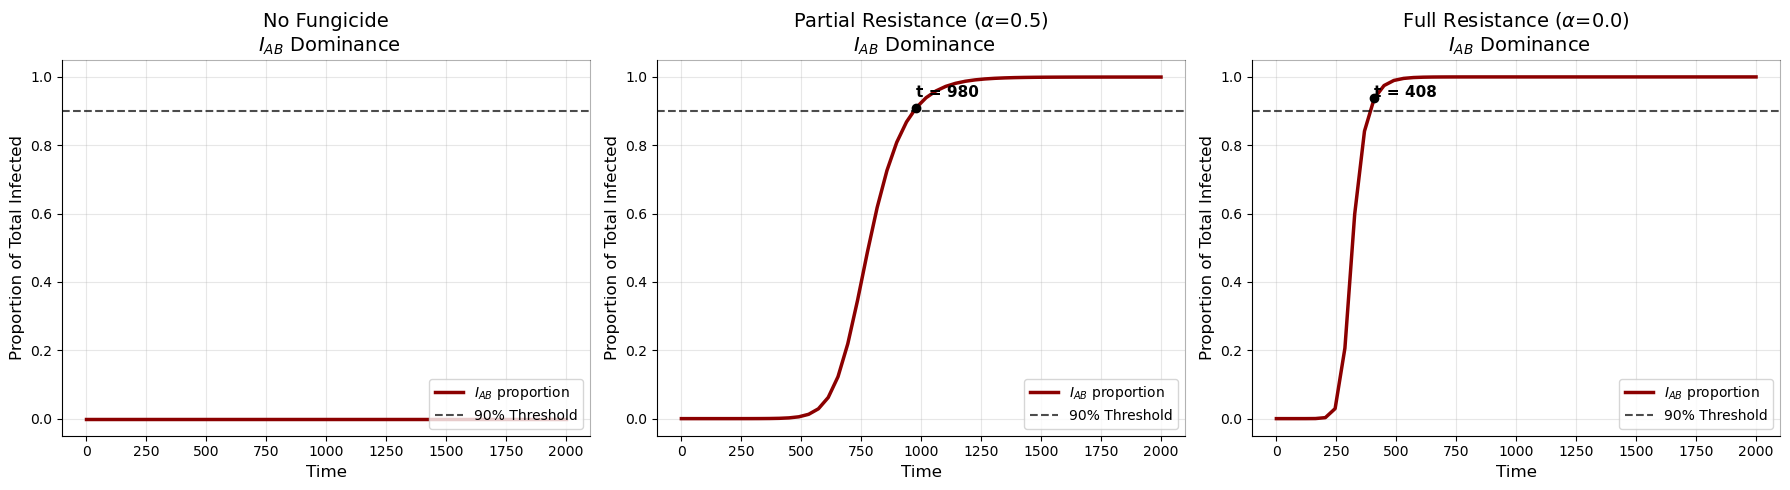

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

def calculate_I_AB_proportion(sol):
    I_total = sol[:, 1] + sol[:, 2] + sol[:, 3] + sol[:, 4]
    return np.divide(sol[:, 4], I_total, out=np.zeros_like(I_total), where=(I_total != 0))

scenarios = [
    ("No Fungicide", sol_no_fungicide),
    ("Partial Resistance ($\\alpha$=0.5)", sol_w_fungicide_05),
    ("Full Resistance ($\\alpha$=0.0)", sol_w_fungicide_0)
]

for i, (title, sol) in enumerate(scenarios):
    ax = axes[i]
    
    I_AB_proportion = calculate_I_AB_proportion(sol)

    ax.plot(t, I_AB_proportion, color='darkred', linewidth=2.5, label='$I_{AB}$ proportion')
    ax.axhline(y=0.9, color='black', linestyle='--', alpha=0.7, label='90% Threshold')

    indices = np.where(I_AB_proportion >= 0.9)[0]

    if len(indices) > 0:
        hit_time = t[indices[0]]
        ax.plot(hit_time, I_AB_proportion[indices[0]], 'ko')
        ax.text(hit_time, 0.94, f't = {hit_time:.0f}', fontsize=11, fontweight='bold')

    ax.set_title(title + "\n $I_{AB}$ Dominance", fontsize=14)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Proportion of Total Infected", fontsize=12)

    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

plt.tight_layout()
plt.show()

#### Disease dynamics time graph

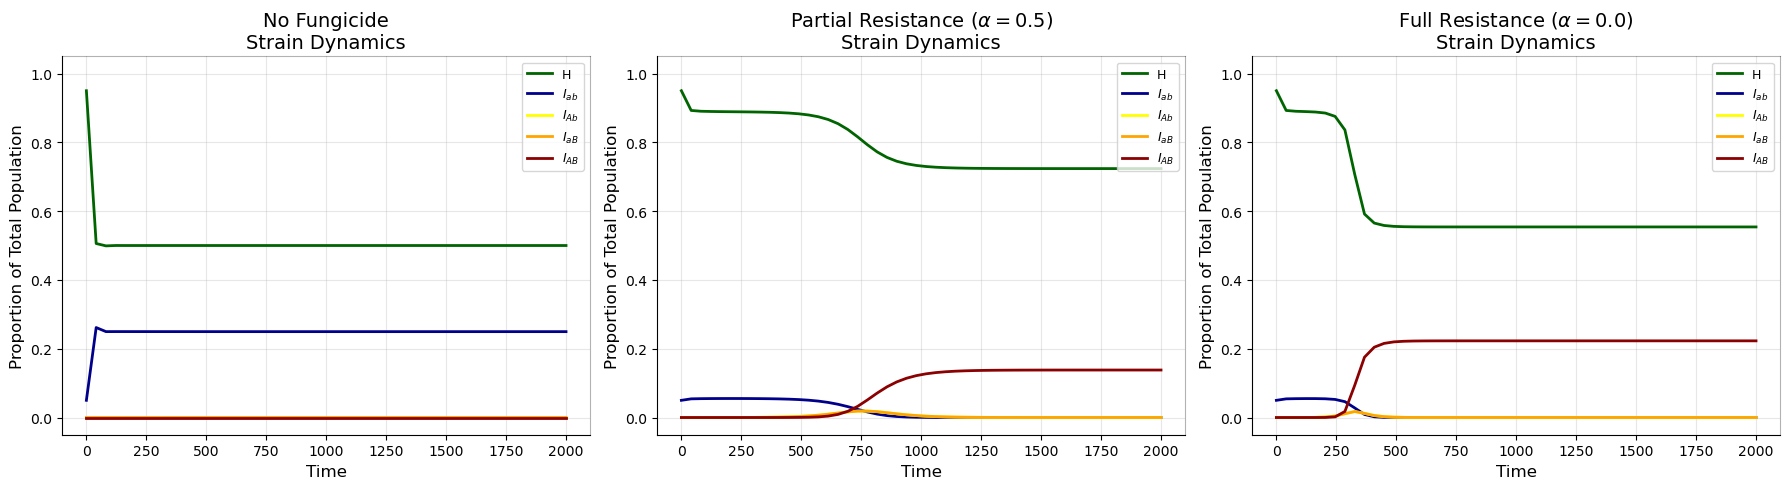

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

scenarios = [
    ("No Fungicide", sol_no_fungicide),
    ("Partial Resistance ($\\alpha=0.5$)", sol_w_fungicide_05),
    ("Full Resistance ($\\alpha=0.0$)", sol_w_fungicide_0)
]

labels = ['H', '$I_{ab}$', '$I_{Ab}$', '$I_{aB}$', '$I_{AB}$']
colors = ['darkgreen', 'darkblue', 'yellow', 'orange', 'darkred']

for i, (title, sol) in enumerate(scenarios):
    ax = axes[i]

    for j in range(5):
        ax.plot(t, sol[:, j], color=colors[j], linewidth=2, label=labels[j])

    ax.set_title(title + "\nStrain Dynamics", fontsize=14)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Proportion of Total Population", fontsize=12)

    ax.set_ylim(-0.05, 1.05)

    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

plt.tight_layout()
plt.show()